# **Insurance Claims & Fraud Analysis**

**Project Type : EDA**

**Project Prepared By : Pranav Thakur**

# Project Summary

This project focuses on performing a comprehensive analysis of an insurance claims dataset to extract meaningful insights. The process begins with data cleaning and preprocessing, including handling missing values and preparing the dataset for analysis Exploratory Data Analysis (EDA) is then conducted to study various aspects such as claim amount distribution, relationships between age and claim amount, and comparisons of fraud occurrence across gender, incident types, and property damage. Correlation analysis is used to identify relationships between numerical variables, while outlier detection helps in identifying unusual claim values. Time-based analysis provides insights into when incidents occur, and Principal Component Analysis (PCA) is applied to reduce dimensionality and visualize data patterns. Overall, the project utilizes Python libraries like Pandas, Matplotlib, Seaborn, and Scikit-learn to perform detailed data analysis.

# **Problem Statement**

The increasing number of insurance claims has made it challenging for companies to identify fraudulent activities efficiently. Manual detection of fraud is time-consuming and often unreliable due to the complexity and volume of data. This project aims to analyze insurance claim data to identify hidden patterns, trends, and anomalies that may indicate fraudulent behavior. By using data analysis techniques, the objective is to understand the key factors influencing claims and support better decision-making for fraud detection.

# **Lets Begin !**

# 1. Know The Data

# Importing Libaries

In [ ]:
# Basic Libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Advanced Visualization
import plotly.express as px

# Missing values visualization
import missingno as msno

# Warnings ignore
import warnings
warnings.filterwarnings('ignore')

# Scaling & PCA
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA


# Dataset Loading

In [ ]:
df = pd.read_csv('insurance_claims.csv')
# Copy dataset
df_clean = df.copy()

# **Dataset First Look**

In [ ]:
print("First 5 Rows:\n")
df_clean.head()

First 5 Rows:



,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


# **Dataset Rows And Columns**

In [ ]:
print("Rows & Columns:",
df_clean.shape)

Rows & Columns: (1000, 40)


# **Dataset Information**

In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level      1000 non-null   object 
 12  insured_occupation           1000 non-null   object 
 13  insured_hobbies    

# **Duplicate Values**

In [ ]:
print("Duplicate Rows:",
df_clean.duplicated().sum())

Duplicate Rows: 0


# **Missing Values**

In [ ]:
df_clean.isnull().sum()

,0
months_as_customer,0
age,0
policy_number,0
policy_bind_date,0
policy_state,0
policy_csl,0
policy_deductable,0
policy_annual_premium,0
umbrella_limit,0
insured_zip,0


**Visualizing Missing Values**

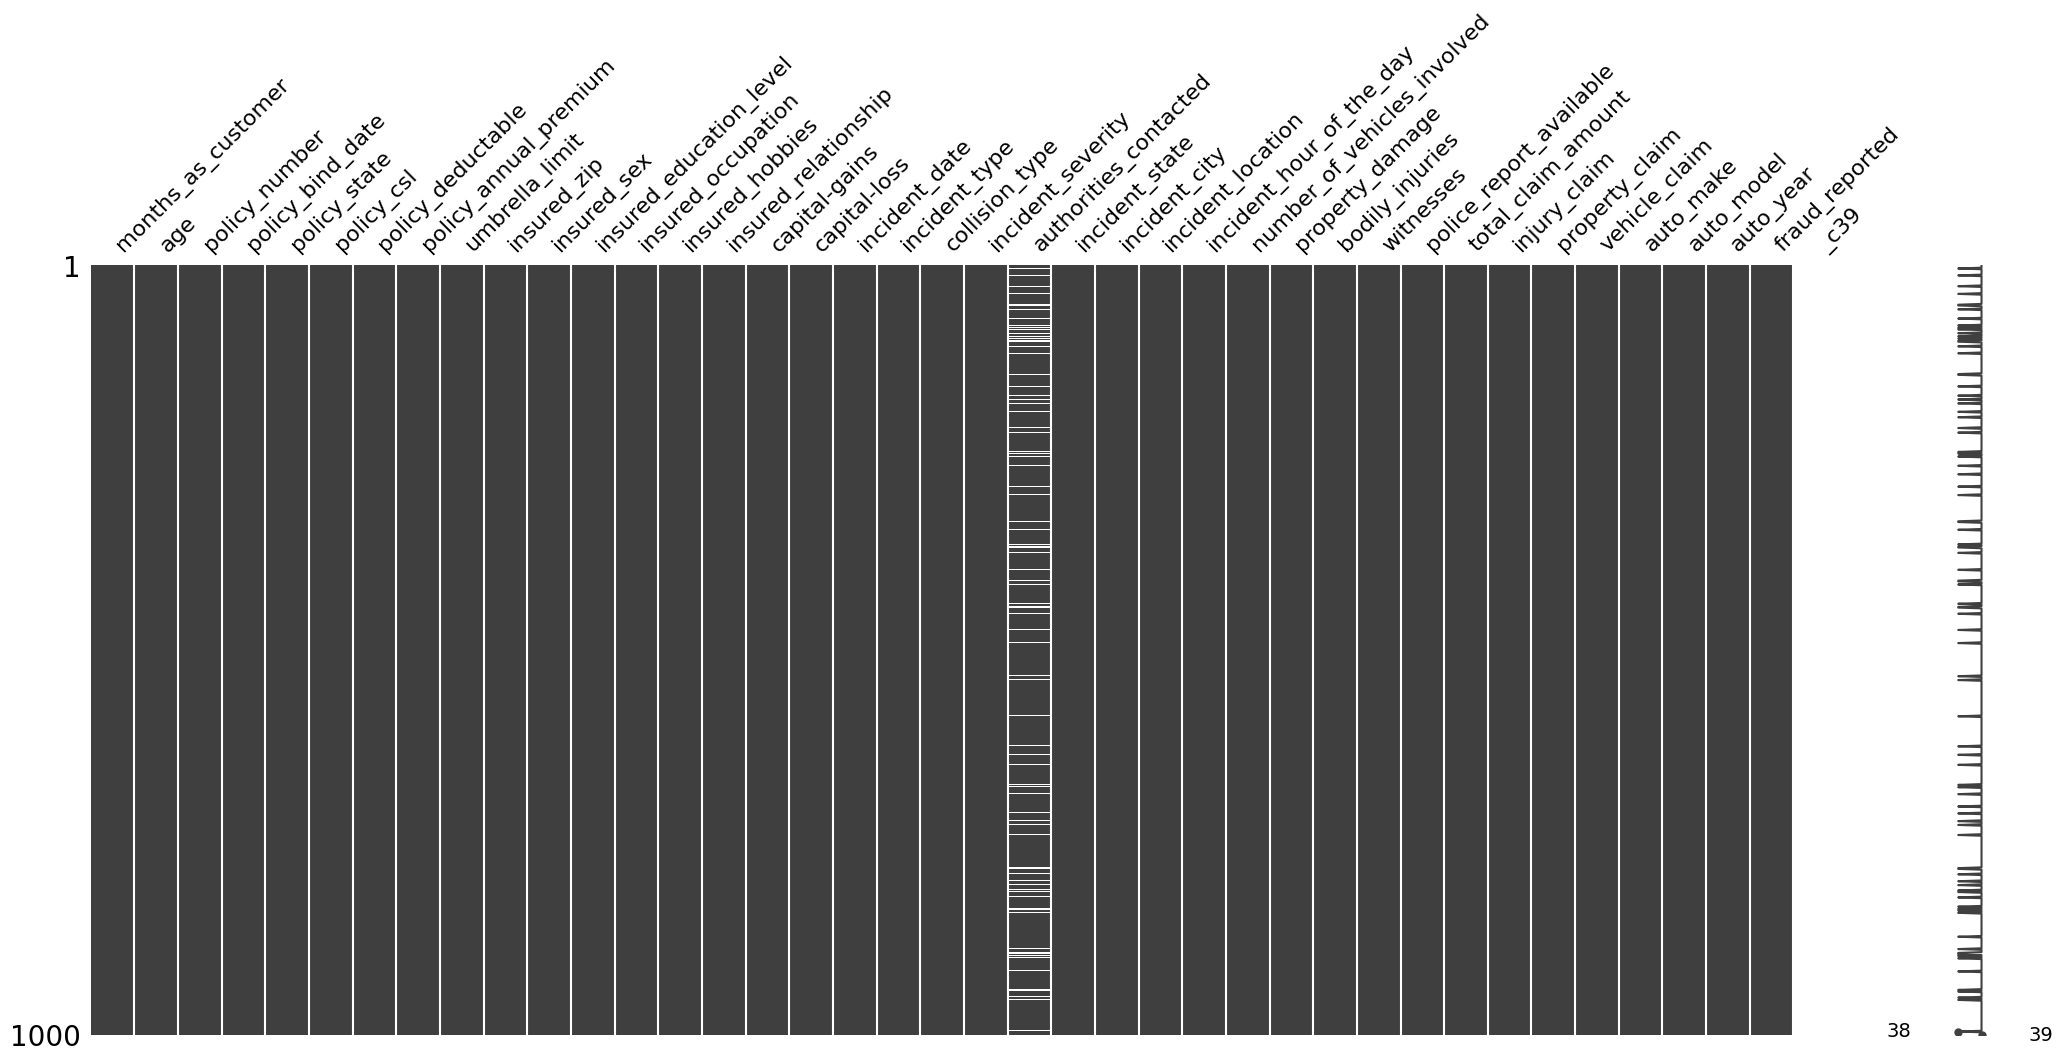

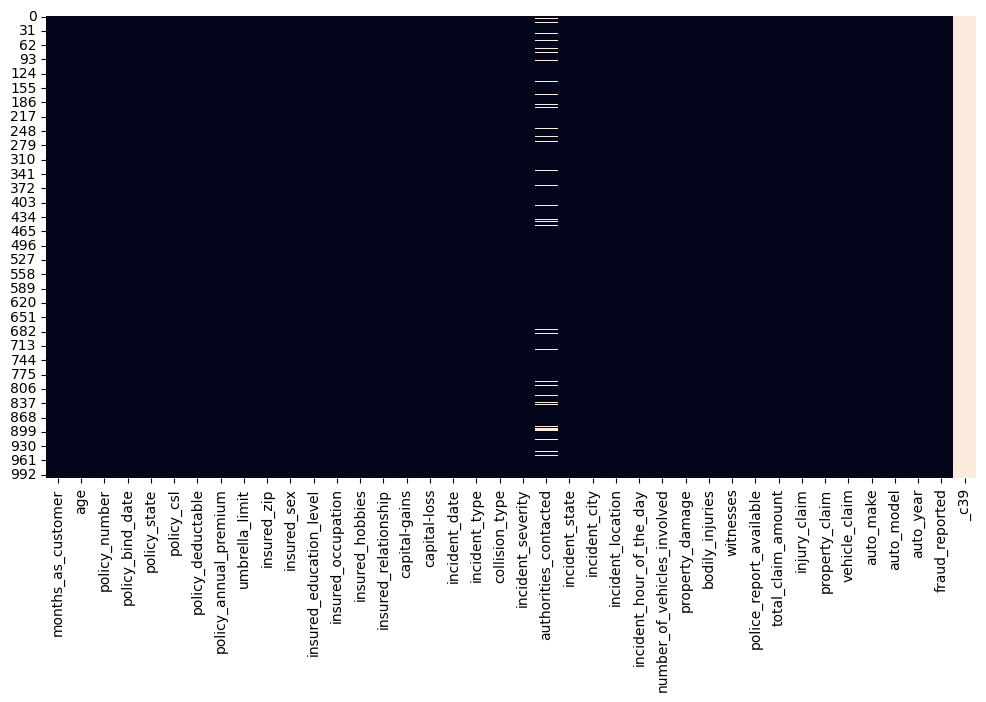

In [ ]:
msno.matrix(df_clean)
plt.show()

plt.figure(figsize=(12,6))
sns.heatmap(df_clean.isnull(), cbar=False)
plt.show()

**What Does This Tell ?**

The dataset contains very few missing values, indicating good data quality with minimal preprocessing required.”



# **Columns & Data Types**

In [ ]:
print("Columns:\n", df_clean.columns)
print("\nData Types:\n", df_clean.dtypes)

Columns:
 Index(['months_as_customer', 'age', 'policy_number', 'policy_bind_date',
       'policy_state', 'policy_csl', 'policy_deductable',
       'policy_annual_premium', 'umbrella_limit', 'insured_zip', 'insured_sex',
       'insured_education_level', 'insured_occupation', 'insured_hobbies',
       'insured_relationship', 'capital-gains', 'capital-loss',
       'incident_date', 'incident_type', 'collision_type', 'incident_severity',
       'authorities_contacted', 'incident_state', 'incident_city',
       'incident_location', 'incident_hour_of_the_day',
       'number_of_vehicles_involved', 'property_damage', 'bodily_injuries',
       'witnesses', 'police_report_available', 'total_claim_amount',
       'injury_claim', 'property_claim', 'vehicle_claim', 'auto_make',
       'auto_model', 'auto_year', 'fraud_reported', '_c39'],
      dtype='object')

Data Types:
 months_as_customer               int64
age                              int64
policy_number                    int64
policy_

# **Statistical Summary**

In [ ]:
df_clean.describe()

,months_as_customer,age,policy_number,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,capital-gains,capital-loss,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_year,_c39
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,0.0
mean,203.954000,38.948000,546238.648000,1136.000000,1256.406150,1.101000e+06,501214.488000,25126.100000,-26793.700000,11.644000,1.83900,0.992000,1.487000,52761.94000,7433.420000,7399.570000,37928.950000,2005.103000,NaN
std,115.113174,9.140287,257063.005276,611.864673,244.167395,2.297407e+06,71701.610941,27872.187708,28104.096686,6.951373,1.01888,0.820127,1.111335,26401.53319,4880.951853,4824.726179,18886.252893,6.015861,NaN
min,0.000000,19.000000,100804.000000,500.000000,433.330000,-1.000000e+06,430104.000000,0.000000,-111100.000000,0.000000,1.00000,0.000000,0.000000,100.00000,0.000000,0.000000,70.000000,1995.000000,NaN
25%,115.750000,32.000000,335980.250000,500.000000,1089.607500,0.000000e+00,448404.500000,0.000000,-51500.000000,6.000000,1.00000,0.000000,1.000000,41812.50000,4295.000000,4445.000000,30292.500000,2000.000000,NaN
50%,199.500000,38.000000,533135.000000,1000.000000,1257.200000,0.000000e+00,466445.500000,0.000000,-23250.000000,12.000000,1.00000,1.000000,1.000000,58055.00000,6775.000000,6750.000000,42100.000000,2005.000000,NaN
75%,276.250000,44.000000,759099.750000,2000.000000,1415.695000,0.000000e+00,603251.000000,51025.000000,0.000000,17.000000,3.00000,2.000000,2.000000,70592.50000,11305.000000,10885.000000,50822.500000,2010.000000,NaN
max,479.000000,64.000000,999435.000000,2000.000000,2047.590000,1.000000e+07,620962.000000,100500.000000,0.000000,23.000000,4.00000,2.000000,3.000000,114920.00000,21450.000000,23670.000000,79560.000000,2015.000000,NaN


What Does This Tell ?

**.** The dataset contains 1000 records with no missing values, so the data is complete.

**.** The average age is around 39 years, meaning most customers are middle-aged.

**.** Customers have been with the company for a long time (~17 years on average), showing loyalty.

**.** The annual premium is moderate, mostly between 400 and 2000.
**.** The deductible values are fixed (500, 1000, 2000), not random.






# **Unique Values**

In [ ]:
df_clean.nunique()

,0
months_as_customer,391
age,46
policy_number,1000
policy_bind_date,951
policy_state,3
policy_csl,3
policy_deductable,3
policy_annual_premium,991
umbrella_limit,11
insured_zip,995


# **Data Wrangling**

**Remove Duplicates**

In [ ]:
df_clean = df_clean.drop_duplicates()
print("Shape after removing duplicates:",
df_clean.shape)

Shape after removing duplicates: (1000, 40)


**Handle Missing Values**

In [ ]:
# Drop the '_c39' column as it contains all NaN values
df_clean = df_clean.drop(columns=['_c39'], errors='ignore')

# Replace '?' with np.nan in all object columns
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = df_clean[col].replace('?', np.nan)

# Numerical columns → median
num_cols = df_clean.select_dtypes(include=np.number).columns

for col in num_cols:
    df_clean[col].fillna(df_clean[col].median(), inplace=True)

# Categorical columns → mode
cat_cols = df_clean.select_dtypes(include='object').columns

for col in cat_cols:
    df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

print("Missing values left:", df_clean.isnull().sum().sum())

Missing values left: 0


**Encoding (Converting Categorical Data to Numeric)**

In [ ]:
df_clean = pd.get_dummies (df_clean, drop_first=True)

**Feature Scaling (Normalization)**

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_clean = pd.DataFrame(scaler.fit_transform(df_clean), columns=df_clean.columns)

# **3. EDA / Data Visualization**

# **1. Distribution of Fraud vs Non-Fraud Cases**

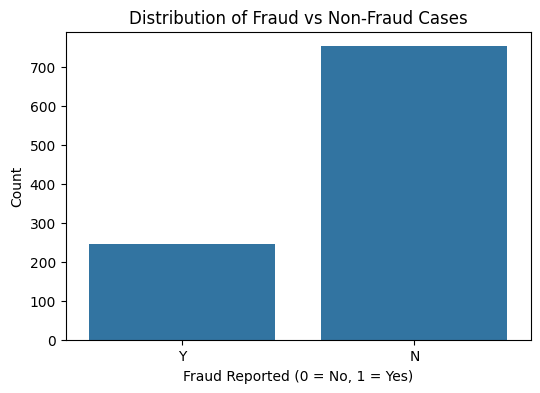

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x=df['fraud_reported'])
plt.title("Distribution of Fraud vs Non-Fraud Cases")
plt.xlabel("Fraud Reported (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

**Why This Chart ?**

To analyze how expenditure is distributed.

**What Does This Chart Show?**

 The chart shows that non-fraud cases (0) are significantly higher than fraud cases (1)

**Insight :**

 Fraud cases are much fewer compared to non-fraud cases.

## **2. Customer Age Distribution**

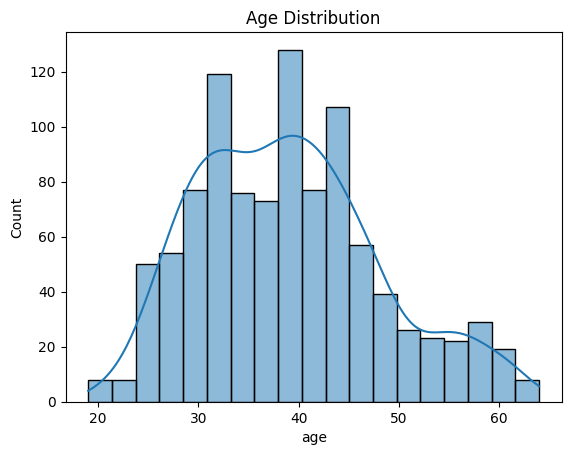

In [ ]:
sns.histplot(df['age'], kde=True)
plt.title("Age Distribution")
plt.show()

**Why This Chart?**


To understand the age pattern of customers in the dataset.

**What Does This Show?**

It shows how customer ages are distributed across different age groups.

**Insight :**

Most customers are between 30 to 50 years.

**Analysis :**

The distribution is fairly normal, indicating a balanced age spread without extreme skewness.

# 3. Customer Tenure Distribution

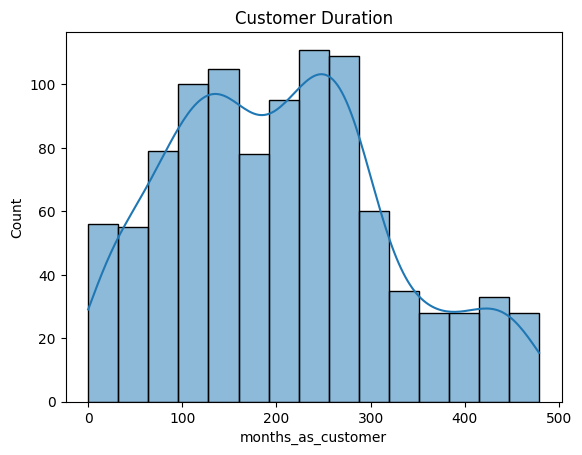

In [ ]:
sns.histplot(df['months_as_customer'], kde=True)
plt.title("Customer Duration")
plt.show()

**Why This Chart?**

To analyze how long customers have been associated with the company.

**What Does This Show?**

It shows the distribution of customer duration in months.

**Insight :**

Customers are spread across a wide range, with many long-term customers.

**Analysis :**

This indicates strong customer retention and a mix of new and experienced customers.

# **4. Annual Policy Premium Distribution**

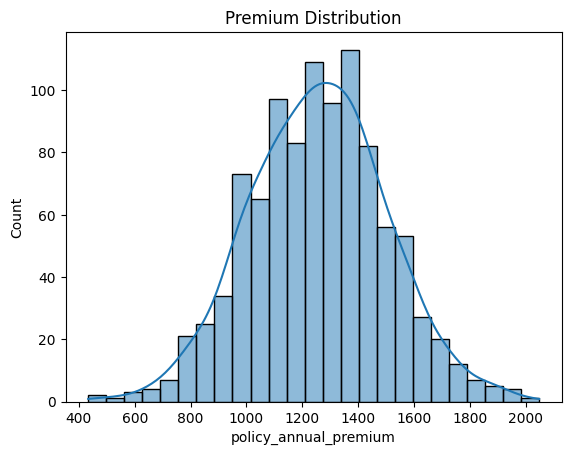

In [ ]:
sns.histplot(df['policy_annual_premium'], kde=True)
plt.title("Premium Distribution")
plt.show()

**Why This Chart?**

 To examine how premium amounts are distributed among customers.

***What Does This Show?***

 It shows the frequency of different premium values.

**Insight :**

Most premium values lie in the mid-range (~1000–1500).

**Analysis :**

The distribution is close to normal, suggesting consistent pricing structure.

# **5. Distribution of Insurance Claim Amounts**

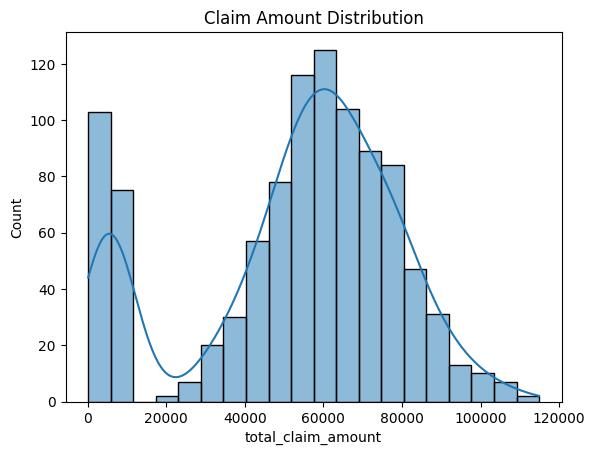

In [ ]:
sns.histplot(df['total_claim_amount'], kde=True)
plt.title("Claim Amount Distribution")
plt.show()

**Why This Chart**?

To analyze the distribution of claim amounts filed by customers.

**What Does This Show?**

It shows how claim amounts vary across the dataset.

**Insight :**

Most claims are in the mid-range (40k–80k), with some extreme values.

**Analysis :**

The distribution is slightly right-skewed, indicating the presence of outliers (high claims).

# **6. Boxplot**

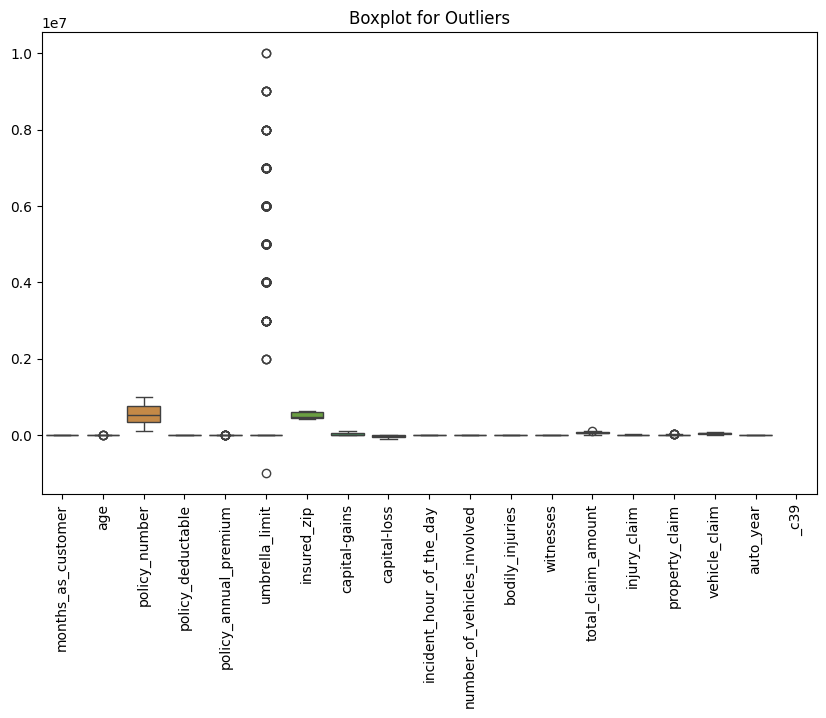

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.title("Boxplot for Outliers")
plt.xticks(rotation=90)
plt.show()

**Why This Chart?**

 To identify outliers and spread in numerical features of the dataset.

**What Does This Chart Show?**

 The boxplot shows:

. Median (center line)

. Spread of data (box = IQR)

. Outliers (points outside whiskers)

**Insight :**




 Several features contain outliers, especially:

. umbrella_limit

. capital-gains / capital-loss

. total_claim_amount


 Some features have tightly packed values, while others show large variation.

**Analysis :**

👉 Presence of outliers indicates:

Extreme or unusual values in the dataset

Possible real-world high-value claims or anomalies

👉 These outliers can:

Affect model performance

Skew the distribution

# **7. Correlation Heatmap**

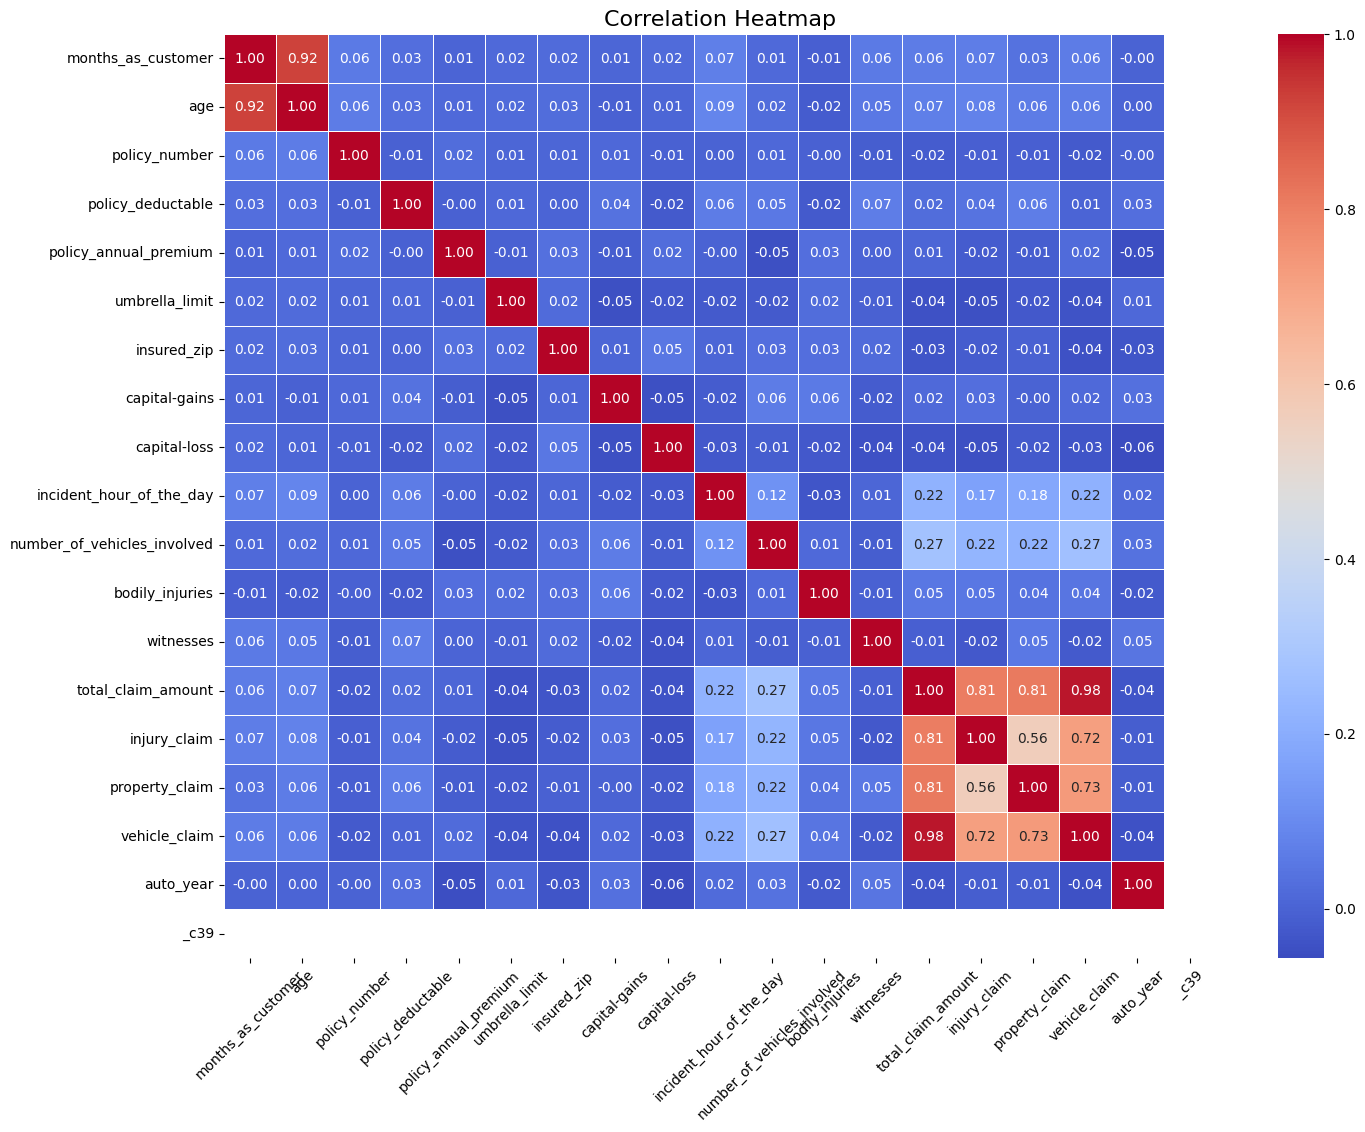

In [ ]:
plt.figure(figsize=(16,12))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=16)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

**Why this chart?**

To understand relationship between numerical features

Helps identify:

**.** Strong relationships 📈

**.** Weak/no relationships 📉

Useful for:

**.** Feature selection

**.** Avoiding multicollinearity

**What does this graph show?**

Values range from -1 to +1
+1 → strong positive correlation

0 → no relation
-1 → strong negative correlation

Color meaning:
🔴 Red → strong positive
🔵 Blue → weak/negative

**Key Insights**

1️⃣ Strong Correlation in Claim Features


total_claim_amount has high correlation with:

injury_claim

property_claim

vehicle_claim

👉 Means:

Total claim = combination of these parts


2️⃣ Age & Customer Duration
age and months_as_customer → high correlation (~0.9)


👉 Insight:

Older customers = longer association with company


3️⃣ Most Features Weakly Correlated
Majority values ~0

👉 Insight:

Features are independent

Good for ML (less redundancy)


4️⃣ No Strong Negative Correlation

Almost no strong negative values



**Analysis :**

The heatmap shows that most features have weak correlations, indicating low multicollinearity.


Strong correlations exist mainly among claim-related variables, which is expected as they contribute to the total claim amount.


Age and customer duration are highly correlated, reflecting real-world behavior.


# **8. Claim Amount Distribution**

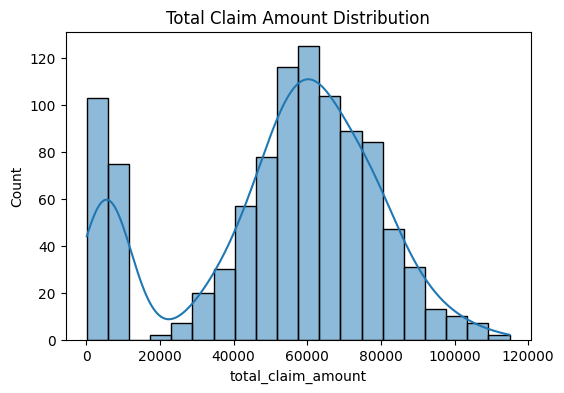

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['total_claim_amount'], kde=True)
plt.title("Total Claim Amount Distribution")
plt.show()

**Why this chart**?

To understand how total claim amounts are distributed


**What does this graph show?**

X-axis → Total Claim Amount

Y-axis → Number of cases

Histogram + KDE curve → distribution shape

***Key Insights***


1️⃣ Most Claims are in Mid Range
Majority of claims are around ₹40,000 – ₹70,000

👉 Insight:

Most insurance claims are moderate, not too low or too high

2️⃣ Right-Skewed Distribution 📈
Tail extends towards higher values

👉 Insight:

Few cases have very high claim amounts
Indicates presence of outliers

3️⃣ Low Amount Cluster
Small spike near lower values (~₹0–₹10,000)

👉 Insight:

Some claims are very small (minor damages)

4️⃣ High Value Outliers ⚠️
Claims going above ₹100,000+

👉 Insight:

Rare but expensive cases (major accidents/fraud possibility)

Analysis

The distribution of total claim amounts is slightly right-skewed, indicating that while most claims fall within a moderate range, a few cases have significantly higher values.

The presence of outliers suggests high-cost claims which may require further investigation.

This distribution is important for understanding risk patterns and can help in fraud detection or claim prediction models.

# **9. Age vs Claim Amount**

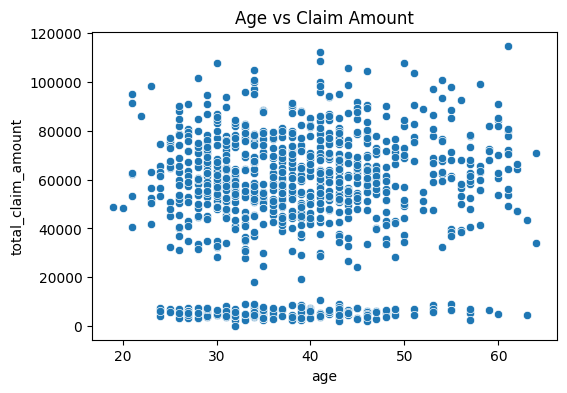

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['age'], y=df['total_claim_amount'])
plt.title("Age vs Claim Amount")
plt.show()

**Why this chart?**

To analyze the relationship between age and claim amount

**What does the chart show?**

The chart shows the relationship between age and total claim amount.

Each point represents a customer’s claim.

The points are scattered randomly, indicating no clear correlation between age and claim amount.

Claims of both low and high values occur across all age groups.

**Insight:**

Most claims are in the ₹40k–₹80k range

**Analysis :**

This suggests that age is not a key factor in determining claim amount.

# **10. Gender vs Fraud**

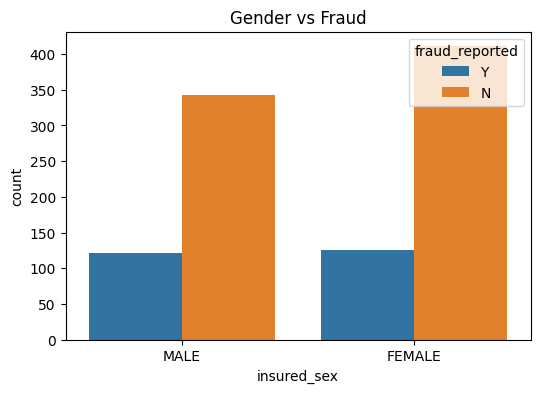

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x=df['insured_sex'], hue=df['fraud_reported'])
plt.title("Gender vs Fraud")
plt.show()

**Why this chart?**

To analyze fraud distribution across genders

**What does the chart show?**

Both males and females have similar fraud and non-fraud counts

Non-fraud cases are higher in both groups

**Insight:**

No major difference in fraud based on gender

Fraud cases are fewer compared to non-fraud

**Analysis:**

Gender does not significantly influence fraud occurrence

# **11. Incident Type Analysis**

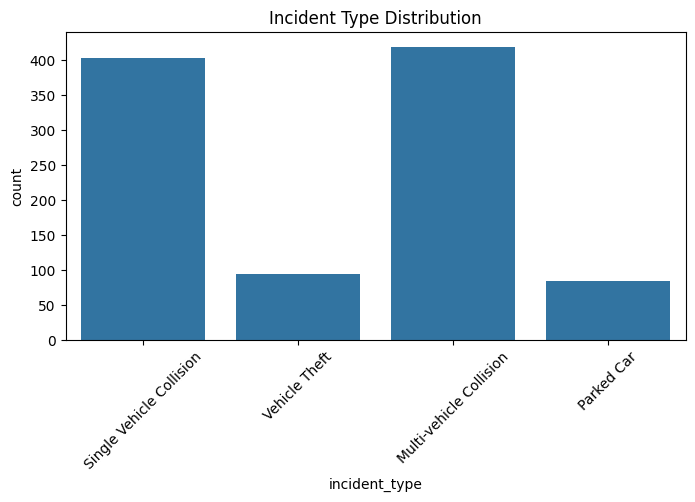

In [ ]:
plt.figure(figsize=(8,4))
sns.countplot(x=df['incident_type'])
plt.title("Incident Type Distribution")
plt.xticks(rotation=45)
plt.show()

**Why this chart?**

To understand distribution of different incident types

**What does the chart show?**

Most incidents are Single Vehicle and Multi-Vehicle Collisions

Vehicle Theft and Parked Car cases are fewer

**Insight:**

Collision-related incidents are most common

Theft-related cases are relatively low

**Analysis:**

Accidents are the primary cause of claims compared to other incident types

# **12. Police Report vs Fraud**

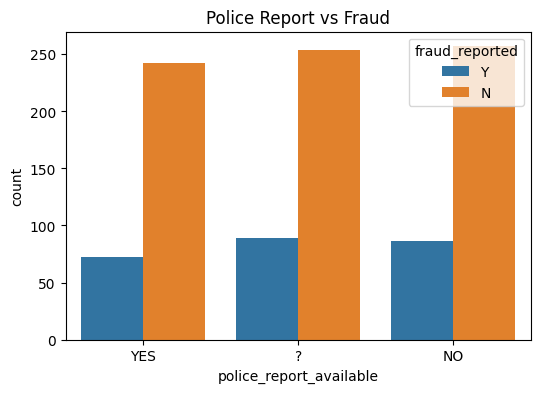

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x=df['police_report_available'], hue=df['fraud_reported'])
df['police_report_available'] = df['police_report_available'].replace('?', 'Unknown')
plt.title("Police Report vs Fraud")
plt.show()

**Why this chart?**

To check if police report availability is linked with fraud cases

**What does the chart show?**

Both males and females have similar fraud and non-fraud counts

Non-fraud cases are higher in both groups

**Insight:**

No major difference in fraud based on gender

Fraud cases are fewer compared to non-fraud

**Analysis:**

Gender does not significantly influence fraud occurrence

# **13. Property Damage vs Fraud**

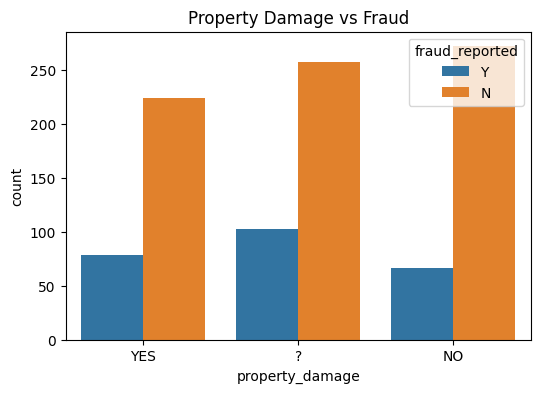

In [ ]:


plt.figure(figsize=(6,4))
sns.countplot(x=df['property_damage'], hue=df['fraud_reported'])
plt.title("Property Damage vs Fraud")
df['police_report_available'] = df['police_report_available'].replace('?', 'Unknown')

**Why this chart?**

To check whether property damage is related to fraud cases

**What does the chart show?**

Fraud cases exist in both



**Insight:**

Property damage alone does not strongly indicate fraud

Fraud cases even occur when there is no property damage

**Analysis:**

Property damage does not significantly impact fraud occurrence

# **14. Time-based Analysis (Incident Hour)**

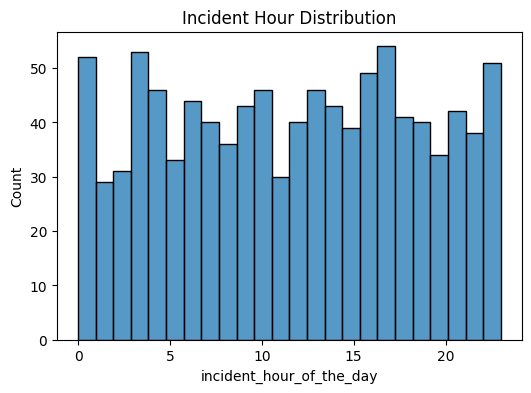

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['incident_hour_of_the_day'], bins=24)
plt.title("Incident Hour Distribution")
plt.show()

**Why this chart?**

To analyze at what time of day incidents occur most frequently

**What does the chart show?**

Incidents are spread across all hours of the day (0–23)

No single hour has an extremely high peak

**Insight**:

Incidents happen throughout the day, not limited to a specific time

**Analysis:**

Time of incident is not a strong standalone factor

# **4. Principal Component Analysis (PCA)**

In [ ]:
y = df_clean['fraud_reported_Y']
X = df_clean.drop(columns=['fraud_reported_Y'])

In [ ]:
y = df_clean['fraud_reported_Y']

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X)

df_pca = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])
df_pca['fraud_reported_Y'] = y

print('Explained variance ratio:', pca.explained_variance_ratio_)
print('\nPCA DataFrame head:\n', df_pca.head())

Explained variance ratio: [0.04492762 0.0244616 ]

PCA DataFrame head:
         PC1       PC2  fraud_reported_Y
0 -0.429219  1.094919               1.0
1  1.491711 -0.240660               1.0
2  0.868589  0.303965               0.0
3  0.108491  0.439981               1.0
4  1.334106 -0.567631               0.0


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

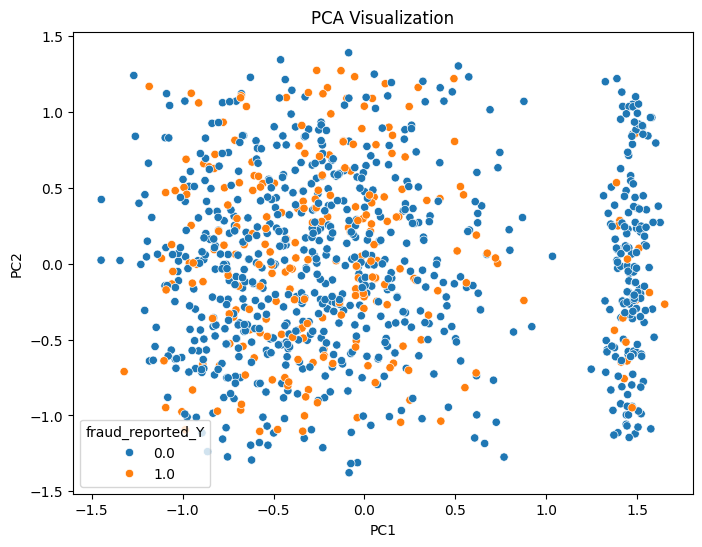

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='PC1', y='PC2', hue='fraud_reported_Y', data=df_pca)

plt.title("PCA Visualization")
plt.show()

**What does the plot show?**

Data points of fraud (1) and non-fraud (0) are highly overlapping

No clear separation between the two classes in PC1 and PC2

**Insight :**
PC1 and PC2 explain very low variance (~0.3% each)



**Conclusion**:

he PCA visualization shows significant overlap between fraud and non-fraud cases, indicating that the selected features do not provide strong separation in reduced dimensions

In [ ]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.00364189 0.00206055]


# **Final Conclution**

The analysis reveals that most insurance claims are non-fraudulent, indicating that fraud cases form a smaller portion of the dataset. Factors such as age and gender do not show a strong influence on fraudulent activity, while certain features like incident type, property damage, and police report availability exhibit some patterns related to fraud. The claim amount distribution shows significant variation with the presence of outliers, suggesting irregular high-value claims. The dataset is largely clean with minimal missing values, which improves the reliability of the analysis. However, the PCA results indicate that fraud and non-fraud cases are not clearly separable using the available features. This suggests that fraud detection is a complex problem that cannot be solved using simple analysis alone and may require advanced machine learning techniques for more accurate predictions.